In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models


In [18]:
df = pd.read_csv('StressLevelDataset.csv')

In [19]:
num_rows = df.shape[0]
print(f"Number of rows: {num_rows}")

Number of rows: 1100


In [20]:
df.head()


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [21]:
X = df.drop('stress_level', axis=1)
y = df['stress_level']

In [ ]:
# Train/Test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax') # Low, Mid, High levels 3 nisa
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6455 - loss: 0.7608 - val_accuracy: 0.8409 - val_loss: 0.5166
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8784 - loss: 0.4226 - val_accuracy: 0.8727 - val_loss: 0.3542
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8818 - loss: 0.2928 - val_accuracy: 0.8682 - val_loss: 0.2843
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8909 - loss: 0.2316 - val_accuracy: 0.8682 - val_loss: 0.2591
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8989 - loss: 0.2024 - val_accuracy: 0.8682 - val_loss: 0.2502
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9136 - loss: 0.1839 - val_accuracy: 0.8773 - val_loss: 0.2460
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9239 - loss: 0.1690 - val_accuracy: 0.8818 - val_loss: 0.2403
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9295 - loss: 0.1565 - val_accuracy: 0.8773 - val_loss

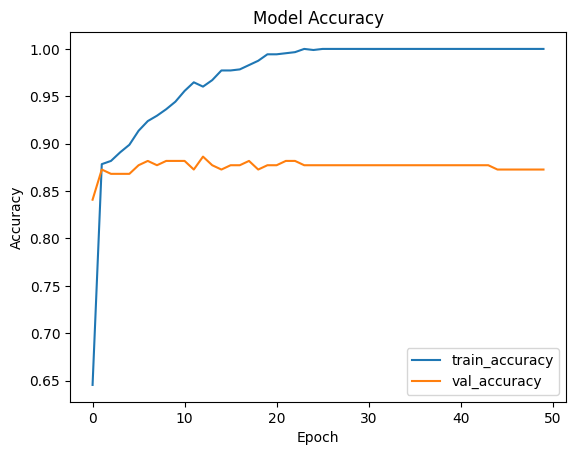

In [ ]:
import matplotlib.pyplot as plt


plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
import joblib
from google.colab import files

joblib.dump(scaler, 'scaler.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

# 1. Test කරන්න දත්ත ටිකක් හදමු (Features 20)
# Pilivela: anxiety_level, self_esteem, mental_health_history, depression,
# headache, blood_pressure, sleep_quality, breathing_problem, noise_level,
# living_conditions, safety, basic_needs, academic_performance, study_load,
# teacher_student_relationship, future_career_concerns, social_support,
# peer_pressure, extracurricular_activities, bullying

# Udaharanayak widiyata "High Stress" wenna puluwan data tikak gammu:
sample_student_data = [20, 5, 1, 25, 3, 3, 2, 4, 4, 2, 2, 1, 1, 5, 1, 5, 1, 5, 1, 5]

# 2. Data tika array ekakata harawa ganna
sample_input = np.array(sample_student_data).reshape(1, -1)

# 3. Model ekata danna kalin Scaling karanna (Meka godak wadagath!)
sample_input_scaled = scaler.transform(sample_input)

# 4. Prediction eka karanna
prediction = model.predict(sample_input_scaled)
predicted_class = np.argmax(prediction)

# 5. Result eka print karanna
stress_levels = {0: "Low Stress", 1: "Medium Stress", 2: "High Stress"}
print(f"Model Prediction: {stress_levels[predicted_class]}")
print(f"Confidence Levels: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Model Prediction: High Stress
Confidence Levels: [[4.6788330e-07 1.5434844e-04 9.9984515e-01]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# 1. TensorFlow.js library eka install karaganna
!pip install tensorflowjs

import tensorflowjs as tfjs

# 2. Oyage 'model' eka JSON format ekata convert karala folder ekakata danna
tfjs.converters.save_keras_model(model, 'tfjs_model')

# 3. Ee folder eka zip ekak widiyata hadanna (Download karanna lesi wenna)
!zip -r tfjs_model.zip tfjs_model

# 4. Zip file eka download karaganna
from google.colab import files
files.download('tfjs_model.zip')

failed to lookup keras version from the file,
    this is likely a weight only file
  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/model.json (deflated 80%)
  adding: tfjs_model/group1-shard1of1.bin (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Colab එකේ මේක run කරන්න
print("Means:", scaler.mean_)
print("Scales:", scaler.scale_)

Means: [11.11818182 17.63522727  0.49659091 12.57840909  2.52954545  2.1875
  2.64545455  2.77613636  2.66818182  2.50568182  2.71818182  2.78295455
  2.77727273  2.60568182  2.63295455  2.66704545  1.87272727  2.76363636
  2.78409091  2.62613636]
Scales: [6.11180946 8.96165493 0.49998838 7.63638046 1.40907441 0.83398176
 1.5393999  1.41377109 1.3164644  1.1190355  1.39971957 1.42762689
 1.42555629 1.32209011 1.39497651 1.53646744 1.04105795 1.42415699
 1.41058389 1.52031653]
